In [17]:
import tensorflow
import keras
import numpy as np
import sklearn as skl
import pandas as pd
import joblib
from matplotlib import pyplot as plt

In [18]:
lf_model_path = 'utils/MLP-ANN.keras'
lf_model = keras.models.load_model(lf_model_path)

In [19]:
def build_pinn_loss(panel_dx: np.ndarray, panel_dy: np.ndarray, lambda_physical: float,
    y_scaler: skl.preprocessing.StandardScaler):
    """
    
    """

    # --- Converting to tensorflow constants ---
    panel_dx = tensorflow.constant(panel_dx, dtype=tensorflow.float32)
    panel_dy = tensorflow.constant(panel_dy, dtype=tensorflow.float32)

    y_mean = y_scaler.mean_.astype(np.float32)
    y_scale = y_scaler.scale_.astype(np.float32)

    Cl_mean = tensorflow.constant(y_mean[0:1].reshape(1, 1), dtype=tensorflow.float32)
    Cl_scale = tensorflow.constant(y_scale[0:1].reshape(1, 1), dtype=tensorflow.float32)

    Cp_mean = tensorflow.constant(y_mean[1:].reshape(1, -1), dtype=tensorflow.float32)
    Cp_scale = tensorflow.constant(y_scale[1:].reshape(1, -1), dtype=tensorflow.float32)

    def pinn_loss(y_true: np.ndarray, y_pred: np.ndarray):
        """
        
        """

        # --- Casting to float32 ---
        y_true = tensorflow.cast(y_true, dtype=tensorflow.float32)
        y_pred = tensorflow.cast(y_pred, dtype=tensorflow.float32)

        # --- Defines the true supervised values ---
        AoA_deg = y_true[:, -1:]

        # --- Defines the predicted supervised values ---
        Cl_pred = y_pred[:, 0:1]
        Cp_pred = y_pred[:, 1:]

        # --- Defines the supervised loss as a global MSE ---
        supervised_true = y_true[:, :-1]
        supervised_pred = y_pred
        data_loss = tensorflow.reduce_mean(tensorflow.square(supervised_true - supervised_pred))

        # --- Reescales the predicted supervised values ---
        Cl_pred_raw = Cl_pred * Cl_scale + Cl_mean
        Cp_pred_raw = Cp_pred * Cp_scale + Cp_mean

        # --- Computes the average Cp for each panel ---
        panel_Cp = 0.5 * (Cp_pred_raw[:, :-1] + Cp_pred_raw[:, 1:])

        # --- Integrates to find normal (Cn) and axial (Ca) force coefficients ---
        Cn = tensorflow.reduce_sum(panel_Cp * panel_dx, axis=1, keepdims=True)
        Ca = -tensorflow.reduce_sum(panel_Cp * panel_dy, axis=1, keepdims=True)

        # --- Defines the angle of attack in radians ---
        AoA_rad = AoA_deg * (np.pi / 180.0)

        # --- Projects Cn and Ca into the lift coefficient (Cl) using the angle of attack ---
        Cl_from_Cp_raw = Cn * tensorflow.cos(AoA_rad) - Ca * tensorflow.sin(AoA_rad)

        # --- Defines the physical loss ---
        physical_loss = tensorflow.reduce_mean(tensorflow.square(Cl_pred_raw - Cl_from_Cp_raw))

        # --- Defines the training loss ---
        loss = data_loss + lambda_physical * physical_loss

        return loss
    
    return pinn_loss

def pinn_supervised_mse(y_true: np.ndarray, y_pred: np.ndarray):
    """
    
    """

    # --- Casting float 32 ---
    y_true = tensorflow.cast(y_true, dtype=tensorflow.float32)
    y_pred = tensorflow.cast(y_pred, dtype=tensorflow.float32)

    # --- Defines the true supervised values, excluding the angle of attack ---
    supervised_true = y_true[:, :-1]

    # --- Calculates the supervised mean squared error ---
    supervised_mse = tensorflow.reduce_mean(tensorflow.square(supervised_true - y_pred))

    return supervised_mse

def pinn_supervised_mae(y_true: np.ndarray, y_pred: np.ndarray):
    """
    
    """

    # --- Casting to float32 ---
    y_true = tensorflow.cast(y_true, dtype=tensorflow.float32)
    y_pred = tensorflow.cast(y_pred, dtype=tensorflow.float32)

    # --- Defines the true supervised values, excluding the angle of attack ---
    supervised_true = y_true[:, :-1]

    # --- Calculates the mean absolute error ---
    supervised_mae = tensorflow.reduce_mean(tensorflow.abs(supervised_true - y_pred))

    return supervised_mae

def build_physical_metric(panel_dx: np.ndarray, panel_dy: np.ndarray, y_scaler: skl.preprocessing.StandardScaler):
    """
    
    """

    # --- Converting to tensorflow constants ---
    panel_dx = tensorflow.constant(panel_dx, dtype=tensorflow.float32)
    panel_dy = tensorflow.constant(panel_dy, dtype=tensorflow.float32)

    y_mean = y_scaler.mean_.astype(np.float32)
    y_scale = y_scaler.scale_.astype(np.float32)

    Cl_mean = tensorflow.constant(y_mean[0:1].reshape(1, 1), dtype=tensorflow.float32)
    Cl_scale = tensorflow.constant(y_scale[0:1].reshape(1, 1), dtype=tensorflow.float32)

    Cp_mean = tensorflow.constant(y_mean[1:].reshape(1, -1), dtype=tensorflow.float32)
    Cp_scale = tensorflow.constant(y_scale[1:].reshape(1, -1), dtype=tensorflow.float32)

    def physical_mse(y_true: np.ndarray, y_pred: np.ndarray):
        """
        
        """

        # --- Casting to float32 ---
        y_true = tensorflow.cast(y_true, dtype=tensorflow.float32)
        y_pred = tensorflow.cast(y_pred, dtype=tensorflow.float32)

        # --- Defines the true and predicted values ---
        Cl_pred = y_pred[:, 0:1]
        Cp_pred = y_pred[:, 1:]
        AoA_deg = y_true[:, -1:]

        # --- Reescales the predicted values ---
        Cl_pred_raw = Cl_pred * Cl_scale + Cl_mean
        Cp_pred_raw = Cp_pred * Cp_scale + Cp_mean

        # --- Computes the average Cp for each panel ---
        panel_Cp = 0.5 * (Cp_pred_raw[:, :-1] + Cp_pred_raw[:, 1:])

        # --- Integrates to find normal (Cn) and axial (Ca) force coefficients ---
        Cn = tensorflow.reduce_sum(panel_Cp * panel_dx, axis=1, keepdims=True)
        Ca = -tensorflow.reduce_sum(panel_Cp * panel_dy, axis=1, keepdims=True)

        # --- Defines the angle of attack in radians ---
        AoA_rad = AoA_deg * (np.pi / 180.0)

        # --- Projects Cn and Ca into the lift coefficient (Cl) using the angle of attack ---
        Cl_from_Cp_raw = Cn * tensorflow.cos(AoA_rad) - Ca * tensorflow.sin(AoA_rad)

        # --- Defines the physical loss ---
        return tensorflow.reduce_mean(tensorflow.square(Cl_pred_raw - Cl_from_Cp_raw))

    return physical_mse

def load_transfer_model(lf_model_path: str, n_frozen_layers: int, learning_rate, panel_dx, panel_dy, y_scaler):
    model = keras.models.load_model(lf_model_path)

    for layer in model.layers[:n_frozen_layers]:
        layer.trainable = False

    for layer in model.layers[n_frozen_layers:]:
        layer.trainable = True

    loss = build_pinn_loss(panel_dx, panel_dy, lambda_physical=0.2, y_scaler=y_scaler)
    physical_metric = build_physical_metric(panel_dx, panel_dy, y_scaler)

    pinn_supervised_mae.__name__ = 'supervised_mae'
    pinn_supervised_mse.__name__ = 'supervised_mse'
    physical_metric.__name__ = 'physical_mse'

    model.compile(optimizer=keras.optimizers.Nadam(learning_rate=learning_rate), loss=loss, 
        metrics=[pinn_supervised_mse, pinn_supervised_mae, physical_metric])
    
    return model

def print_trainable_layers(model):
    for i, layer in enumerate(model.layers):
        status = 'trainable' if layer.trainable else 'frozen'
        print(f'{i:02d} | {layer.name} | {status}')

In [20]:
def match_effective_angle_cases(data, AoA_effective_data):

    hf_cases = data[['Re', 'AoA', 'y']].to_numpy(dtype=np.float64)
    lf_cases = AoA_effective_data[['Re', 'AoA', 'y']].to_numpy(dtype=np.float64)

    std_values = AoA_effective_data[['Re', 'AoA', 'y']].std().to_numpy(dtype=np.float64)

    AoA_effective_values = AoA_effective_data['AoA_Effective'].to_numpy(dtype=np.float64)

    matched_AoA_effective = []

    for case in hf_cases:
        distance = np.sqrt(
            ((lf_cases[:, 0] - case[0]) / std_values[0]) ** 2 +
            ((lf_cases[:, 1] - case[1]) / std_values[1]) ** 2 +
            ((lf_cases[:, 2] - case[2]) / std_values[2]) ** 2)
        
        closest_idx = np.argmin(distance)
        matched_AoA_effective.append(AoA_effective_values[closest_idx])

    matched_AoA_effective = np.array(matched_AoA_effective, dtype=np.float32)

    return matched_AoA_effective

def load_and_split_data_generalization_y(filepath, AoA_effective, test_y_value=0.781856397):

    data = (pd.read_csv(filepath, sep=';')).copy()
    data['AoA_Effective'] = match_effective_angle_cases(data=data, AoA_effective_data=AoA_effective)
    
    wing_sections = 1
    idx = np.arange(len(data))
    data['flow_case'] = idx // wing_sections

    test_mask = np.isclose(data['y'].astype(float), test_y_value, atol=1e-8)

    data_test = data[test_mask].copy().reset_index(drop=True)
    data_remaining = data[~test_mask].copy()

    unique_cases = data_remaining['flow_case'].unique()

    train_cases, val_cases = skl.model_selection.train_test_split(unique_cases, test_size=0.2,
        random_state=42, shuffle=True)
    
    # --- Separate the datasets ---
    data_train = data_remaining[data_remaining['flow_case'].isin(train_cases)]
    data_val = data_remaining[data_remaining['flow_case'].isin(val_cases)].drop(columns=['flow_case'])

    return data_train, data_val, data_test

def preprocess_data(data_train, data_val, data_test, X_scaler):

    X_cols = ['Re', 'AoA', 'y']
    y_cols = ['cl'] + [col for col in data_train.columns[4:] if col != 'AoA_Effective' and col != 'flow_case']

    X_train_raw = data_train[X_cols].to_numpy()
    X_val_raw = data_val[X_cols].to_numpy()
    X_test_raw = data_test[X_cols].to_numpy()

    AoA_train_raw = data_train[['AoA_Effective']].to_numpy()
    AoA_val_raw = data_val[['AoA_Effective']].to_numpy()
    AoA_test_raw = data_test[['AoA_Effective']].to_numpy()

    y_train_raw = data_train[y_cols].to_numpy()
    y_val_raw = data_val[y_cols].to_numpy()
    y_test_raw = data_test[y_cols].to_numpy()

    X_train = X_scaler.transform(X_train_raw)
    X_val = X_scaler.transform(X_val_raw)
    X_test = X_scaler.transform(X_test_raw)

    y_scaler_hf = skl.preprocessing.StandardScaler()
    y_train = y_scaler_hf.fit_transform(y_train_raw)
    y_val = y_scaler_hf.transform(y_val_raw)
    y_test = y_scaler_hf.transform(y_test_raw)

    y_train = np.hstack((y_train, AoA_train_raw))
    y_val = np.hstack((y_val, AoA_val_raw))

    return X_train, y_train, X_val, y_val, X_test, y_test, y_scaler_hf

airfoil_data = pd.read_csv('utils/NACA23015.csv', sep=',', names=['x', 'y'])
AoA_effective_data = pd.read_csv('utils/LowFidelity-AoAEffectiveData.csv', sep=';')
panel_dx = np.diff(airfoil_data['x'].values).astype(np.float32)
panel_dy = np.diff(airfoil_data['y'].values).astype(np.float32)
X_scaler = joblib.load('utils/mlp_ann_X_scaler.pkl')
y_scaler_lf = joblib.load('utils/mlp_ann_y_scaler.pkl')

data_train, data_val, data_test = load_and_split_data_generalization_y('utils/HighFidelity-AviationInterpolated-PressureDistributionData.csv', AoA_effective_data, test_y_value=0.623510444) 

X_train_hf, y_train_hf, X_val_hf, y_val_hf, X_test_hf, y_test_hf, y_scaler_hf = preprocess_data(data_train, data_val, data_test, X_scaler)

transfer_model = load_transfer_model(lf_model_path, n_frozen_layers=3, learning_rate=1e-4, panel_dx=panel_dx, panel_dy=panel_dy, y_scaler=y_scaler_hf)
print_trainable_layers(transfer_model)

00 | Input_Layer | frozen
01 | Hidden_Layer_1 | frozen
02 | Hidden_Layer_2 | frozen
03 | Hidden_Layer_3 | trainable
04 | Hidden_Layer_4 | trainable
05 | Hidden_Layer_5 | trainable
06 | Output_Layer | trainable


In [21]:
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, min_delta=1e-6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint(filepath='tl-frozen-layers.keras',
        monitor='val_loss', save_best_only=True, verbose=1)]

loss = build_pinn_loss(panel_dx, panel_dy, lambda_physical=0.2, y_scaler=y_scaler_hf)

history = transfer_model.fit(X_train_hf, y_train_hf, validation_data=(X_val_hf, y_val_hf), epochs=500, batch_size=32,
    callbacks=callbacks, verbose=1)

Epoch 1/500
17/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7052 - physical_mse: 0.0011 - supervised_mae: 0.5920 - supervised_mse: 0.7050
Epoch 1: val_loss improved from None to 0.63099, saving model to tl-frozen-layers.keras

Epoch 1: finished saving model to tl-frozen-layers.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.6917 - physical_mse: 0.0011 - supervised_mae: 0.5832 - supervised_mse: 0.6858 - val_loss: 0.6310 - val_physical_mse: 9.4876e-04 - val_supervised_mae: 0.5584 - val_supervised_mse: 0.6302 - learning_rate: 1.0000e-04
Epoch 2/500
19/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6547 - physical_mse: 9.6887e-04 - supervised_mae: 0.5634 - supervised_mse: 0.6545
Epoch 2: val_loss improved from 0.63099 to 0.57380, saving model to tl-frozen-layers.keras

Epoch 2: finished saving model to tl-frozen-layers.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6284 - physical_mse: 8.5268e-04 - supervised_mae: 0.5598 - supervised_mse: 0.6306 - val_loss: 0.5738 - val_phy

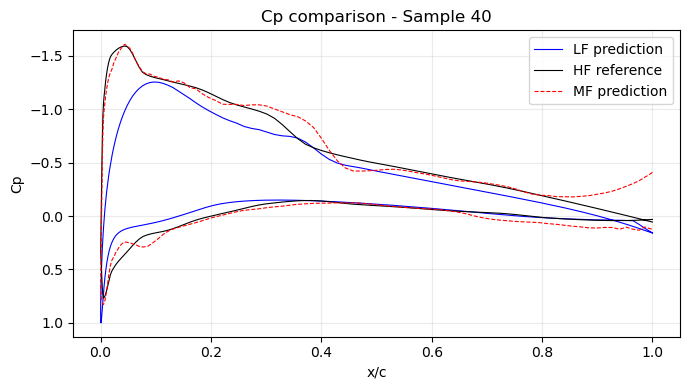

In [27]:
def inverse_transform_y(y_scaled, y_scaler):
    return y_scaler.inverse_transform(y_scaled)

def predict_real_scale(model, X_scaled, y_scaler):
    y_pred_scaled = model.predict(X_scaled, verbose=0)
    y_pred_real = inverse_transform_y(y_pred_scaled, y_scaler)
    return y_pred_real

y_hf_real = inverse_transform_y(y_test_hf, y_scaler_hf)

y_lf_pred_real = predict_real_scale(model=lf_model, X_scaled=X_test_hf, y_scaler=y_scaler_lf)

y_mf_pred_real = predict_real_scale(model=transfer_model, X_scaled=X_test_hf, y_scaler=y_scaler_hf)

def plot_cp_comparison_lf_hf_mf(x_cp, y_lf, y_hf, y_mf, sample_idx, case_info=None, invert_yaxis=True, figsize=(7, 4)):
    plt.figure(figsize=figsize)

    plt.plot(x_cp, y_lf[sample_idx][1:], linestyle='-', linewidth=0.8, label='LF prediction', color='b')
    plt.plot(x_cp, y_hf[sample_idx][1:], linestyle='-', linewidth=0.8, label='HF reference', color='k')
    plt.plot(x_cp, y_mf[sample_idx][1:], linestyle='--', linewidth=0.8, label='MF prediction', color='r')

    plt.xlabel('x/c')
    plt.ylabel('Cp')

    if invert_yaxis:
        plt.gca().invert_yaxis()

    title = f'Cp comparison - Sample {sample_idx}'

    if case_info is not None:
        info_text = ', '.join([f'{k}={v}' for k, v in case_info.items()])
        title += f'\n{info_text}'

    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return

sample_idx = 40

with open('utils/LowFidelity-PressureDistributionData.csv', 'r', encoding='utf-8') as f:
    header = f.readline().strip()

headers = header.split(';')

x_cp = np.array([float(col) for col in headers[4:]])

plot_cp_comparison_lf_hf_mf(
    x_cp=x_cp,
    y_lf=y_lf_pred_real,
    y_hf=y_hf_real,
    y_mf=y_mf_pred_real,
    sample_idx=sample_idx)

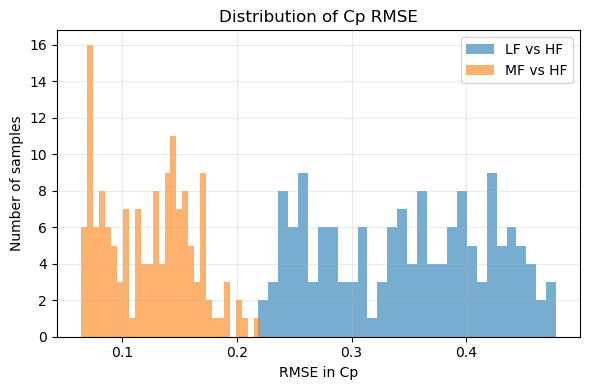

In [23]:
def compute_sample_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=1))

rmse_lf = compute_sample_rmse(y_hf_real, y_lf_pred_real)
rmse_mf = compute_sample_rmse(y_hf_real, y_mf_pred_real)

improvement = rmse_lf - rmse_mf

comparison_df = pd.DataFrame({
    'sample_idx': np.arange(len(rmse_lf)),
    'rmse_lf_vs_hf': rmse_lf,
    'rmse_mf_vs_hf': rmse_mf,
    'improvement_lf_minus_mf': improvement,
    'relative_improvement_percent': 100 * improvement / rmse_lf
})

comparison_df = comparison_df.sort_values(
    by='improvement_lf_minus_mf',
    ascending=False
)

plt.figure(figsize=(6, 4))

plt.hist(rmse_lf, bins=30, alpha=0.6, label='LF vs HF')
plt.hist(rmse_mf, bins=30, alpha=0.6, label='MF vs HF')

plt.xlabel('RMSE in Cp')
plt.ylabel('Number of samples')
plt.title('Distribution of Cp RMSE')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

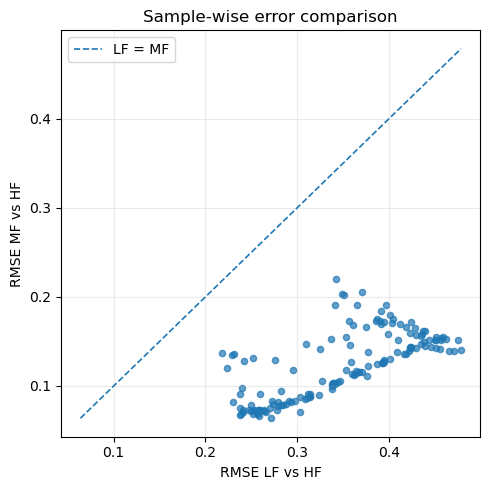

In [24]:
plt.figure(figsize=(5, 5))

plt.scatter(rmse_lf, rmse_mf, s=20, alpha=0.7)

min_value = min(rmse_lf.min(), rmse_mf.min())
max_value = max(rmse_lf.max(), rmse_mf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--',
    linewidth=1.2,
    label='LF = MF'
)

plt.xlabel('RMSE LF vs HF')
plt.ylabel('RMSE MF vs HF')
plt.title('Sample-wise error comparison')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
def compute_global_metrics(y_true, y_pred, label='Model'):
    """
    Compute global regression metrics in physical scale.
    """

    error = y_true - y_pred

    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(error))

    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return {
        'model': label,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }


metrics_df = pd.DataFrame([
    compute_global_metrics(y_hf_real, y_lf_pred_real, label='LF'),
    compute_global_metrics(y_hf_real, y_mf_pred_real, label='MF')
])

print(metrics_df)

  model       MSE      RMSE       MAE        R2
0    LF  0.126066  0.355057  0.192638  0.781992
1    MF  0.016597  0.128831  0.074752  0.971298
